# E-Commerce Customer Churn & Retention Analysis
## 05 — Visualization

### Objective
This notebook translates the strongest findings from the churn analysis and customer segmentation into a concise set of business-focused visuals using **Matplotlib**. The purpose is communication rather than additional exploratory analysis: each chart highlights a finding that is relevant to understanding churn and prioritizing retention efforts.


## Setup
Load the cleaned customer dataset and create the output directory used to save the final figures.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_excel("../Data/E Commerce Dataset Cleaned.xlsx")

figures_path = Path("../outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)


## 1. Overall Customer Churn
The first visual establishes the scale of the churn problem by comparing retained and churned customers. The churn rate is shown alongside the customer counts to provide the headline KPI for the analysis.


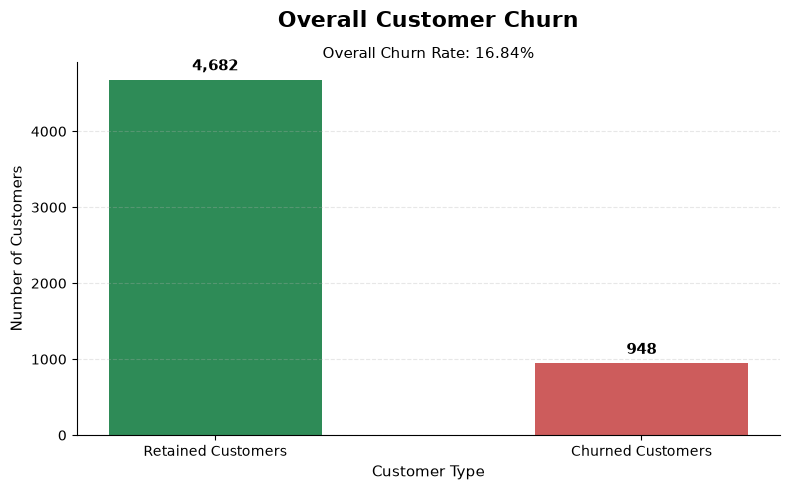

In [2]:
churned_customers = df.loc[df["Churn"] == 1, "CustomerID"].count()
retained_customers = df.loc[df["Churn"] == 0, "CustomerID"].count()
churn_rate = df["Churn"].mean() * 100

customer_type = ["Retained Customers", "Churned Customers"]
customer_count = [retained_customers, churned_customers]

plt.figure(figsize=(8, 5))
bar = plt.bar(customer_type, customer_count, color=["seagreen", "indianred"], width=0.5)

plt.title("Overall Customer Churn", fontsize=16, fontweight="bold", pad=25)
plt.text(0.5, 1.01, f"Overall Churn Rate: {churn_rate:.2f}%",
         transform=plt.gca().transAxes, ha="center", fontsize=11)
plt.xlabel("Customer Type", fontsize=11)
plt.ylabel("Number of Customers", fontsize=11)
plt.bar_label(bar, fmt="{:,.0f}", padding=4, fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_path / "01_overall_customer_churn.png", dpi=300, bbox_inches="tight")
plt.show()


**Finding:** Overall churn is **16.84%**, with 948 churned customers compared with 4,682 retained customers. This provides the baseline against which the remaining customer groups are compared.


## 2. Churn Rate by Tenure Group
Customer tenure was one of the strongest lifecycle signals identified earlier. This visual compares churn rates across tenure groups to show where churn is concentrated in the customer lifecycle.


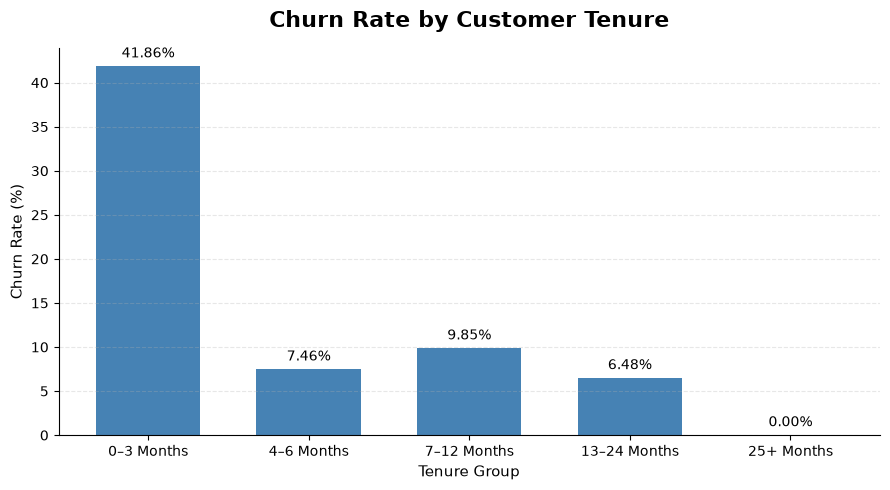

In [3]:
tenure_labels = ["0–3 Months", "4–6 Months", "7–12 Months", "13–24 Months", "25+ Months"]

tenure_group = pd.cut(
    df["Tenure"],
    bins=[-1, 3, 6, 12, 24, float("inf")],
    labels=tenure_labels
)

tenure_churn = (
    df.assign(TenureGroup=tenure_group)
      .groupby("TenureGroup", observed=False)["Churn"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(9, 5))
bars = plt.bar(tenure_churn.index.astype(str), tenure_churn.values, color="steelblue", width=0.65)

plt.title("Churn Rate by Customer Tenure", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Tenure Group", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.bar_label(bars, labels=[f"{v:.2f}%" for v in tenure_churn.values], padding=4, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_path / "02_churn_by_tenure.png", dpi=300, bbox_inches="tight")
plt.show()


**Finding:** Churn is heavily concentrated among customers in their first **0–3 months**, where the churn rate reaches **41.86%**. Churn drops sharply after this initial period, making early customer tenure a key retention window.


## 3. Churn Rate by Complaint Status
Complaint history produced one of the clearest differences in churn. This comparison shows whether customers who raised a complaint experienced a materially different churn rate from those who did not.


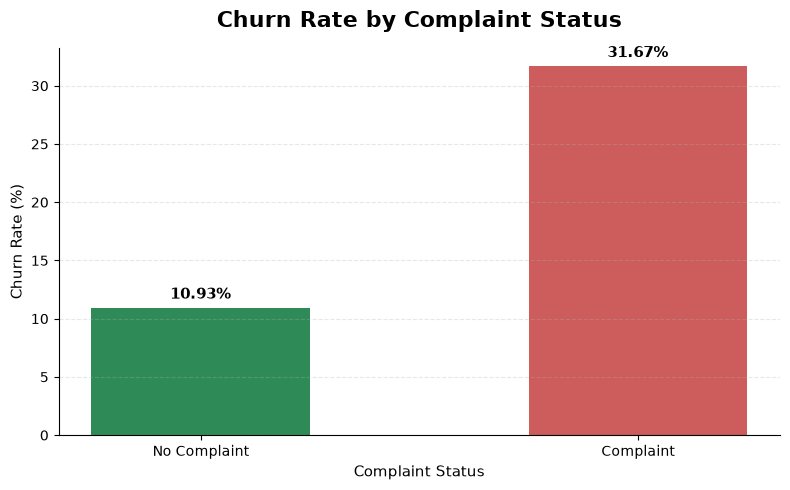

In [4]:
complaint_churn = df.groupby("Complain")["Churn"].mean().mul(100)
complaint_labels = ["No Complaint", "Complaint"]

plt.figure(figsize=(8, 5))
bars = plt.bar(complaint_labels, complaint_churn.values, color=["seagreen", "indianred"], width=0.5)

plt.title("Churn Rate by Complaint Status", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Complaint Status", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.bar_label(bars, labels=[f"{v:.2f}%" for v in complaint_churn.values], padding=4, fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_path / "03_churn_by_complaint.png", dpi=300, bbox_inches="tight")
plt.show()


**Finding:** Customers with a complaint show a **31.67%** churn rate compared with **10.93%** among customers without a complaint. Complaint history is therefore strongly associated with churn in this dataset.


## 4. Churn Rate by Preferred Order Category
Churn also varies across customers' preferred product categories. Comparing category-level churn helps identify where customer retention outcomes differ most noticeably.


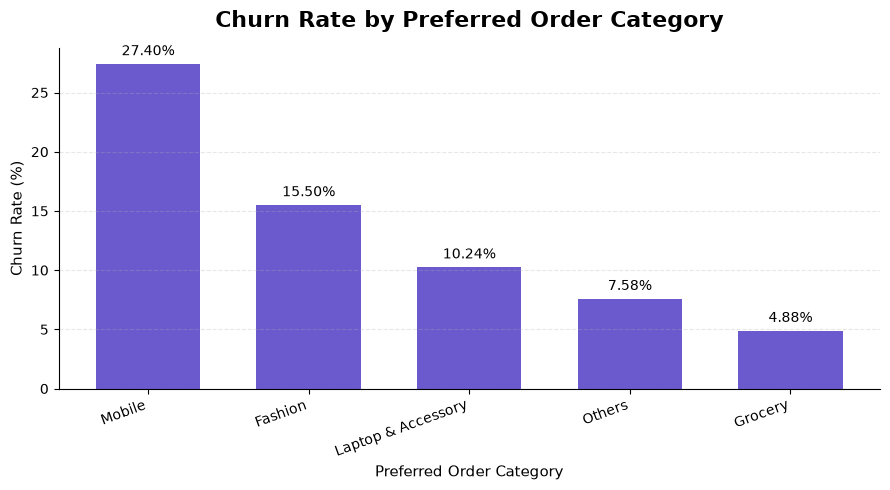

In [5]:
category_churn = (
    df.groupby("PreferedOrderCat")["Churn"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
bars = plt.bar(category_churn.index, category_churn.values, color="slateblue", width=0.65)

plt.title("Churn Rate by Preferred Order Category", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Preferred Order Category", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.bar_label(bars, labels=[f"{v:.2f}%" for v in category_churn.values], padding=4, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=20, ha="right")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_path / "04_churn_by_order_category.png", dpi=300, bbox_inches="tight")
plt.show()


**Finding:** Customers who prefer the **Mobile** category have the highest observed churn rate at **27.40%**, while Grocery customers have the lowest at **4.88%**. This suggests that retention performance differs meaningfully across preferred order categories.


## 5. Churn Rate by Number of Registered Devices
The number of devices registered by a customer showed a clear pattern in the earlier analysis. This chart visualizes how churn changes as the number of registered devices increases.


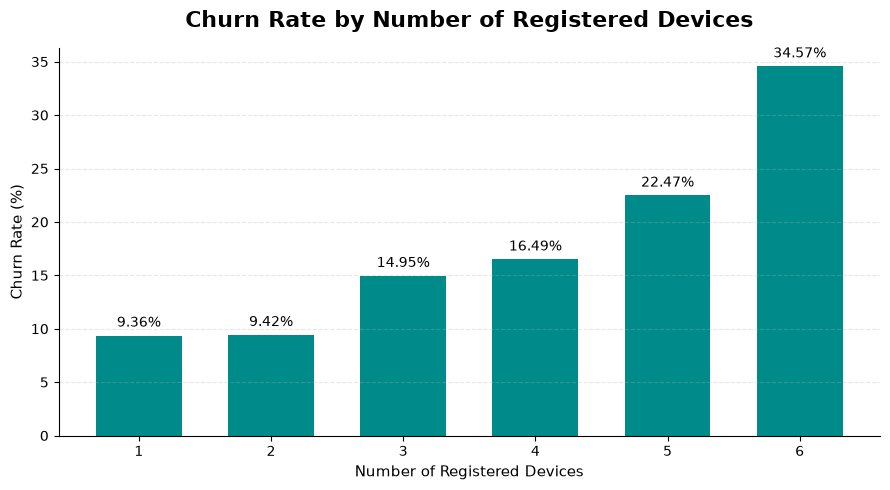

In [6]:
device_churn = (
    df.groupby("NumberOfDeviceRegistered")["Churn"]
      .mean()
      .mul(100)
      .sort_index()
)

plt.figure(figsize=(9, 5))
bars = plt.bar(device_churn.index.astype(str), device_churn.values, color="darkcyan", width=0.65)

plt.title("Churn Rate by Number of Registered Devices", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Number of Registered Devices", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.bar_label(bars, labels=[f"{v:.2f}%" for v in device_churn.values], padding=4, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_path / "05_churn_by_registered_devices.png", dpi=300, bbox_inches="tight")
plt.show()


**Finding:** Churn generally rises as the number of registered devices increases, from **9.36%** for one device to **22.47%** for five devices. The six-device group reaches **34.57%**, although that group is smaller and should be interpreted more cautiously.


## 6. Churn Rate by Customer Risk Segment
The final visual combines the two strongest and most actionable signals—**customer tenure** and **complaint history**. Customers are divided into four segments to show how these factors interact and to identify the groups that should receive the greatest retention attention.


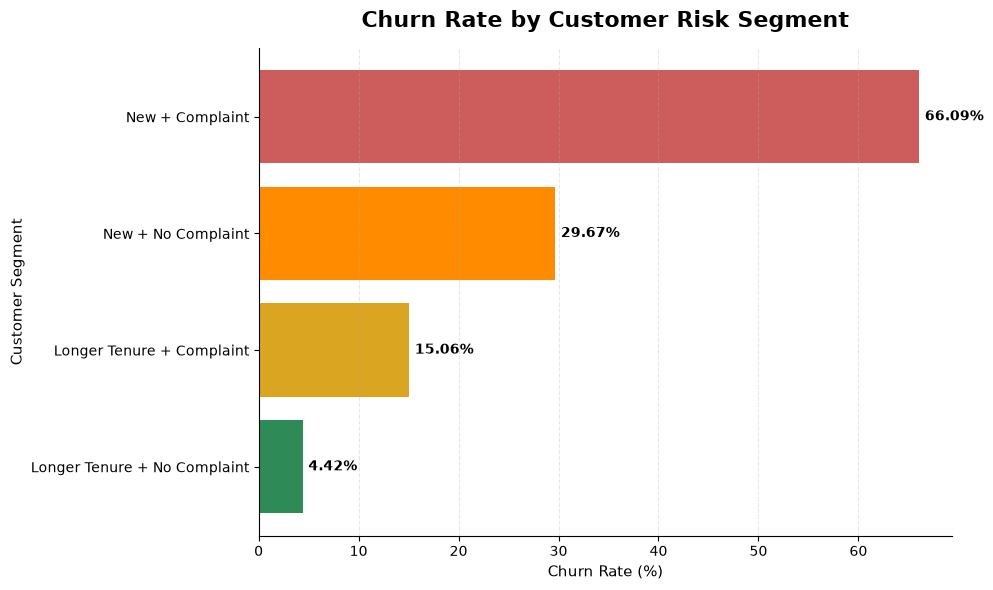

In [7]:
segment = pd.Series(index=df.index, dtype="object")
segment[(df["Tenure"] <= 3) & (df["Complain"] == 1)] = "New + Complaint"
segment[(df["Tenure"] <= 3) & (df["Complain"] == 0)] = "New + No Complaint"
segment[(df["Tenure"] > 3) & (df["Complain"] == 1)] = "Longer Tenure + Complaint"
segment[(df["Tenure"] > 3) & (df["Complain"] == 0)] = "Longer Tenure + No Complaint"

segment_order = [
    "Longer Tenure + No Complaint",
    "Longer Tenure + Complaint",
    "New + No Complaint",
    "New + Complaint"
]

segment_churn = (
    df.assign(RiskSegment=segment)
      .groupby("RiskSegment")["Churn"]
      .mean()
      .mul(100)
      .reindex(segment_order)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(segment_churn.index, segment_churn.values, color=["seagreen", "goldenrod", "darkorange", "indianred"])

plt.title("Churn Rate by Customer Risk Segment", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Churn Rate (%)", fontsize=11)
plt.ylabel("Customer Segment", fontsize=11)
plt.bar_label(bars, labels=[f"{v:.2f}%" for v in segment_churn.values], padding=4, fontsize=10, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_path / "06_churn_by_risk_segment.png", dpi=300, bbox_inches="tight")
plt.show()


**Finding:** The segmentation reveals a clear risk progression. Longer-tenure customers without complaints have the lowest churn rate at **4.42%**, while **new customers with a complaint reach 66.09% churn**. New customers who complain are therefore the highest-priority retention group identified in this analysis.


## Visualization Summary
Across the six visuals, the strongest churn patterns are concentrated around the **early customer lifecycle** and **complaint experience**. Category preference and registered-device count provide additional behavioural context, while the combined tenure-and-complaint segmentation produces the clearest retention priority.

These visuals summarize associations observed in the dataset; they should not be interpreted as proof that any individual factor causes churn. The next notebook converts these findings into business insights, retention priorities, recommendations, and limitations.
